In [1]:
# Colab drive mount skipped (running locally)


**KNN IMPLEMENTATION**

Import libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

loading dataset

In [3]:
df = pd.read_csv('/home/claude/online_shoppers_intention.csv')
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Exploratory data analysis

In [4]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(12330, 18)


In [5]:
print(df.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')


In [6]:
print(df.dtypes)

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object


NULL Values count

In [7]:
print(df.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


Statistical summary

In [8]:
print(df.describe())

       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%                  0.000000        7.00000

Revenue distribution

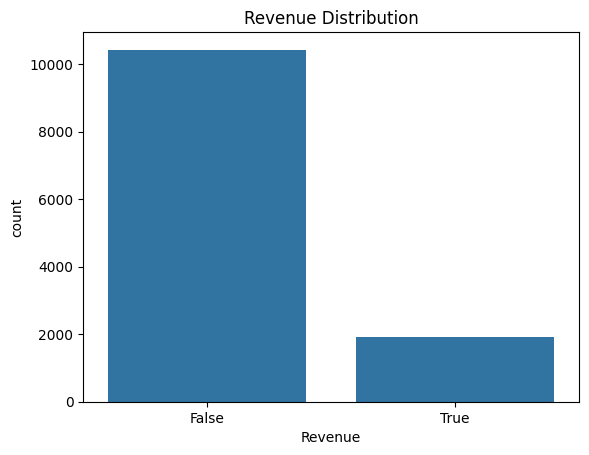

In [9]:
sns.countplot(x='Revenue', data=df)
plt.title("Revenue Distribution")
plt.show()

Data cleaning

In [10]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

Duplicates: 125


New Shape: (12205, 18)


Again check missing values

In [11]:
print(df.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


Encode catagorical data

In [12]:
le = LabelEncoder()
df['Revenue'] = le.fit_transform(df['Revenue'])
df['Weekend'] = le.fit_transform(df['Weekend'])
df['VisitorType'] = le.fit_transform(df['VisitorType'])
df['Month'] = le.fit_transform(df['Month'])

Features +target split

In [13]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

Feature Selection

train test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Oversampling technique

In [15]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [16]:
selector = SelectKBest(mutual_info_classif, k=10)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]
print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Administrative_Duration', 'Informational_Duration', 'ProductRelated',
       'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues',
       'SpecialDay', 'TrafficType', 'VisitorType'],
      dtype='str')


feature scailing

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

finding best k

In [18]:
best_k = 1
best_score = 0
k_values = []
acc_values = []
f1_values = []

max_k = min(30, int(np.sqrt(len(X_train))))

for k in range(3, max_k + 1):

    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance'
    )

    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    k_values.append(k)
    acc_values.append(acc)
    f1_values.append(f1)

    score = (acc + f1) / 2

    print("K =", k, "Acc =", acc, "F1 =", f1)

    if score > best_score:
        best_score = score
        best_k = k

print("\nBest K:", best_k)
print("Best Score:", best_score)


K = 3 Acc = 0.8242523555919705 F1 = 0.5238623751387348


K = 4 Acc = 0.8258910282671037 F1 = 0.5208568207440811


K = 5 Acc = 0.8201556739041377 F1 = 0.5264293419633226


K = 6 Acc = 0.8283490372798034 F1 = 0.5420765027322404


K = 7 Acc = 0.8271200327734535 F1 = 0.5442764578833693


K = 8 Acc = 0.8332650553052028 F1 = 0.5551912568306011


K = 9 Acc = 0.82916837361737 F1 = 0.5462459194776932


K = 10 Acc = 0.8324457189676362 F1 = 0.5510428100987925


K = 11 Acc = 0.8308070462925031 F1 = 0.5515743756786102


K = 12 Acc = 0.8373617369930356 F1 = 0.5632563256325632


K = 13 Acc = 0.8320360507988529 F1 = 0.5553145336225597


K = 14 Acc = 0.8357230643179026 F1 = 0.56078860898138


K = 15 Acc = 0.8357230643179026 F1 = 0.56078860898138


K = 16 Acc = 0.8402294141745187 F1 = 0.5695364238410596


K = 17 Acc = 0.8377714051618189 F1 = 0.5657894736842105


K = 18 Acc = 0.840639082343302 F1 = 0.5720572057205721


K = 19 Acc = 0.8369520688242523 F1 = 0.5626373626373626


K = 20 Acc = 0.8398197460057354 F1 = 0.5669988925802879


K = 21 Acc = 0.8373617369930356 F1 = 0.5642151481888035


K = 22 Acc = 0.8361327324866857 F1 = 0.5652173913043478


K = 23 Acc = 0.8361327324866857 F1 = 0.5652173913043478


K = 24 Acc = 0.8361327324866857 F1 = 0.5652173913043478


K = 25 Acc = 0.836542400655469 F1 = 0.5648854961832062
K = 26 Acc = 0.8373617369930356 F1 = 0.5651697699890471


K = 27 Acc = 0.8353133961491193 F1 = 0.5620915032679739
K = 28 Acc = 0.8340843916427694 F1 = 0.5612134344528711


K = 29 Acc = 0.8336747234739861 F1 = 0.5606060606060606
K = 30 Acc = 0.8353133961491193 F1 = 0.5658747300215983

Best K: 18
Best Score: 0.706348144031937


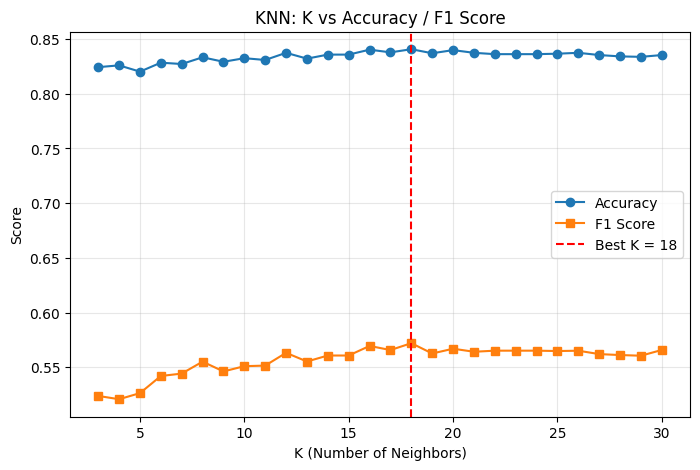

In [19]:
plt.figure(figsize=(8,5))
plt.plot(k_values, acc_values, marker='o', label='Accuracy')
plt.plot(k_values, f1_values, marker='s', label='F1 Score')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Score')
plt.title('KNN: K vs Accuracy / F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


model training

In [20]:
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance'
)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",18
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


prediction

In [21]:
y_pred = knn.predict(X_test)
print(y_pred)

[0 1 0 ... 0 0 1]


Actual vs predicted value

In [22]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(result.head(10))

   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0


Evaluation metrices

In [23]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print(
    "\nConfusion Matrix:\n",
    confusion_matrix(y_test, y_pred)
)
print(
    "\nClassification Report:\n",
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.840639082343302
Precision: 0.4753199268738574
Recall: 0.7182320441988951
F1 Score: 0.5720572057205721

Confusion Matrix:
 [[1792  287]
 [ 102  260]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.86      0.90      2079
           1       0.48      0.72      0.57       362

    accuracy                           0.84      2441
   macro avg       0.71      0.79      0.74      2441
weighted avg       0.88      0.84      0.85      2441



Model Interpretation and Conclusion

The model shows good overall performance with an accuracy of approximately 83%. The recall for class 1 (buyers) is 0.71, which indicates that the model is able to correctly identify a large portion of positive cases. However, the precision for class 1 is relatively lower (0.45), meaning that some non-buyers are incorrectly classified as buyers.

This indicates a trade-off between precision and recall, where the model is optimized more towards identifying positive cases rather than minimizing false positives. Overall, the model is suitable for scenarios where detecting positive cases is more important than avoiding false alarms, and it performs better compared to the initial imbalanced model.

Confusion matrix

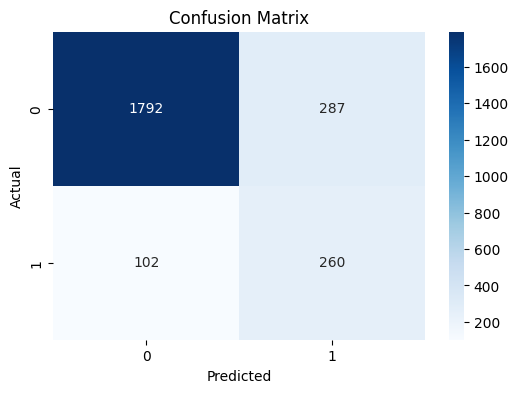

In [24]:
cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "Confusion Matrix"
)
plt.show()